# 32 — `lines`

`Map.lines` draws **line features** — rivers, roads, tracks, pipe or reach networks — and can style them from
their own attributes: a colour ramp by value, a classification scheme, a width. It is the general-purpose line
renderer, where `sankey` (the next notebook) is the special case that sizes width by magnitude.

By the end you will be able to draw a line network, colour it by a value, classify it into bins, and set widths
and plain colours.

API: [`Map.lines`](../../reference/static_map.md).

**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")


## The data

36 reaches of the Rhine and its tributaries, each a `MultiLineString` carrying a `RiverCode` (which river) and a
`length` (how long the reach is).

In [2]:
rivers = FeatureCollection.read_file(str(DATA / "rhine_river_centerline.geojson"))
print(f"{len(rivers)} reaches, EPSG:{rivers.crs.to_epsg()}")
print(f"{rivers['RiverCode'].nunique()} rivers:", ", ".join(sorted(rivers["RiverCode"].unique())))
rivers[["RiverCode", "ReachCode", "length"]].head()

36 reaches, EPSG:3035
12 rivers: Kocher, Lahn, Lippe, Main, Mosel, Nahe, Neckar, Rhine1, Rhine2, Ruhr, Saar, Sieg


,RiverCode,ReachCode,length
0,Lippe,Lippe_A,0.511808
1,Sieg,Sieg_A,0.541289
2,Main,Main_A,0.394722
3,Ruhr,Ruhr_A,0.389358
4,Lahn,Lahn_A,0.505485


`length` runs from 0.4 to about 205 units, so there is a wide spread to colour by.

## Quickstart — the network

With no styling, `lines` draws every feature in one colour. That is the map you want first: it shows the shape
of the network before any value is layered on.

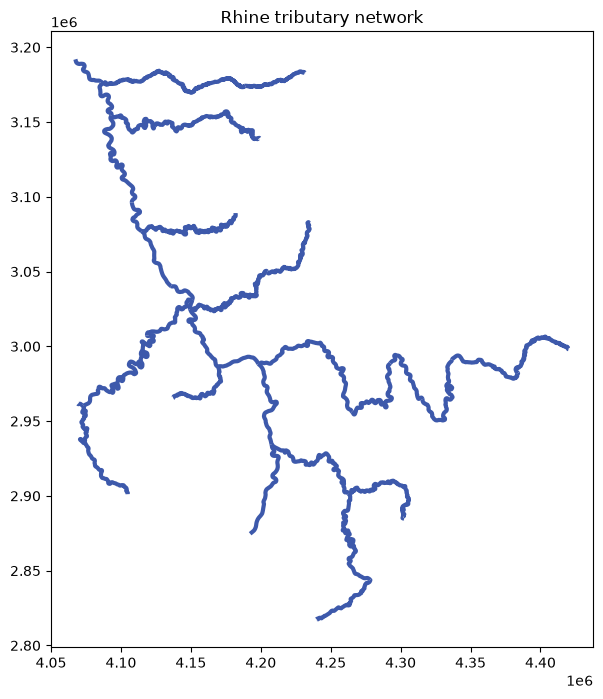

In [3]:
m = Map(crs=rivers.crs.to_epsg(), figsize=(7, 8))
m.lines(rivers)
m.set_title("Rhine tributary network")
m.fig;

The Rhine runs north through the middle with the Mosel, Main, Neckar, Ruhr and Lippe joining it. This is the
skeleton every later figure in this notebook decorates.

## Colouring by a value

`column=` ramps the line colour over a numeric attribute — here reach length, so long trunk reaches separate
from short headwater ones.

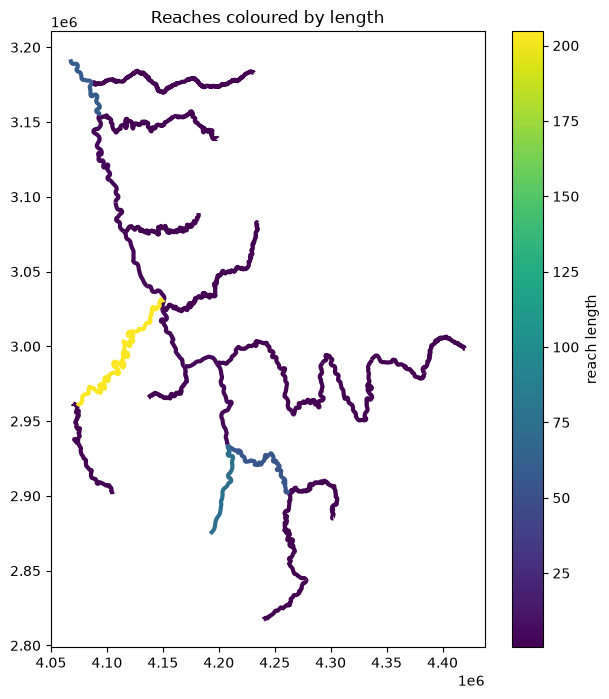

In [4]:
m = Map(crs=rivers.crs.to_epsg(), figsize=(7, 8))
m.lines(rivers, column="length", cmap="viridis")
m.colorbar(label="reach length")
m.set_title("Reaches coloured by length")
m.fig;

The continuous ramp is good for seeing the overall gradient but poor for reading an individual reach's value —
most of the network sits in the dark end because the distribution is skewed toward short reaches.

## Classifying with `scheme` and `k`

A classification scheme fixes the skew by putting the same *number of features* (or an equal value range) in each
class, so every colour is actually used.

| argument | meaning | typical value |
|---|---|---|
| `column` | attribute driving the colour | a numeric column |
| `scheme` | how values are binned | `"quantiles"`, `"equal_interval"`, `"natural_breaks"` |
| `k` | number of classes | `5` (default) |
| `cmap` | colour map | any matplotlib name |
| `width` | line width, or a column name to size by | a number or column name |
| `color` | one flat colour for every line | a colour string |

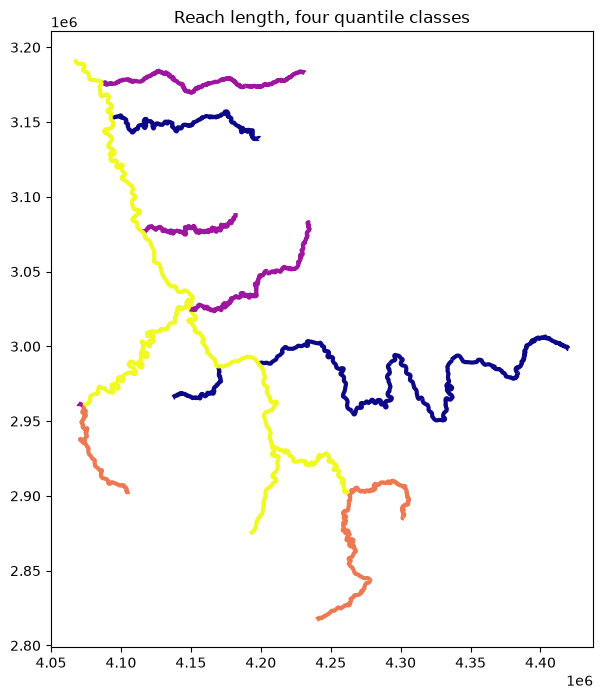

In [5]:
m = Map(crs=rivers.crs.to_epsg(), figsize=(7, 8))
m.lines(rivers, column="length", scheme="quantiles", k=4, cmap="plasma")
m.set_title("Reach length, four quantile classes")
m.fig;

Four quantile classes, nine reaches each. Now the short headwaters are a distinct colour instead of being
crushed into one end of a ramp, and the legend becomes something a reader can match by eye.

## Flat colour and explicit width

For a basemap-style layer you usually want neither a ramp nor a legend — just a thin, quiet line under the data
that matters. `color` and `width` do that.

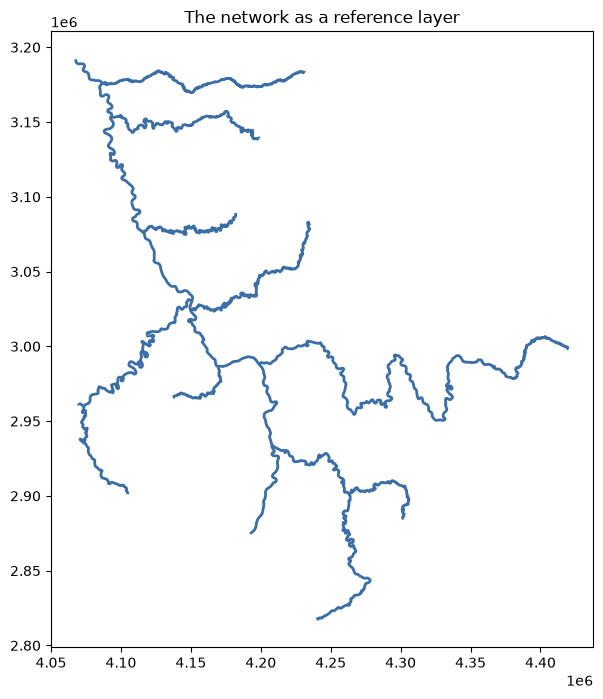

In [6]:
m = Map(crs=rivers.crs.to_epsg(), figsize=(7, 8))
m.lines(rivers, color="#3b6ea5", width=2.0)
m.set_title("The network as a reference layer")
m.fig;

This is the form to reach for when the lines are context rather than content — drawn once, in one colour, and
left to recede behind the layer you actually want read.

## Takeaway

- `lines(features)` draws the network; `column=` ramps colour over an attribute.
- `scheme=` + `k=` classify a skewed attribute so every colour earns its place.
- `color=` and `width=` give the quiet reference-layer form.
- For width that encodes magnitude — a flow map — use [`33_sankey`](33_sankey.ipynb) instead.

Next: [`33_sankey`](33_sankey.ipynb).